# Physics-informed learning across stacks — Part 1: policy export

**The series.** "Physics-informed" means different things in different toolchains, and the difference is architectural, not cosmetic. Classical physics-informed neural networks enforce the governing equations through a *residual loss* evaluated at sampled points. [NEUROMANCER](https://github.com/pnnl/neuromancer) — PNNL's PyTorch library for differentiable programming and differentiable predictive control (DPC) — sits in that tradition: physics enters through the loss function and through structured architectures such as bounded policy networks. Jaxonomy takes the complementary route: physics lives in the *solver* — an ODE/DAE right-hand side integrated by a differentiable simulator, so trajectories satisfy the dynamics by construction rather than by penalty (the distinction is spelled out in [the scope note on PINNs](../scope/pinn.md)). The two philosophies compose well, and this three-part series works through the concrete integration patterns, all on the same physical system — a two-tank pump-and-valve network:

![Three integration patterns](media/pinn_across_stacks_patterns.svg)

- **Part 1 (this notebook) — export and embed.** Train a DPC policy in NEUROMANCER, freeze it to ONNX, and embed it in a jaxonomy diagram as a JAX-traceable block. No gradients cross the stack boundary; the payoff is bit-level validation plus `jit`+`vmap` robustness sweeps at a cost the exporting stack cannot match.
- **[Part 2 — gradients cross the boundary](pinn_across_stacks_part_2_neural_dae.ipynb).** A neural correction learned *inside* an acausal DAE through the implicit BDF solve, and a PyTorch policy trained through the jaxonomy plant via `dlpack`.
- **[Part 3 — tool-neutral FMI co-simulation](pinn_across_stacks_part_3_fmi_cosim.ipynb).** The jaxonomy plant exported as an FMU and stepped in lockstep with the PyTorch policy — verification with no shared runtime at all.

**This part.** We take a neural level controller trained in NEUROMANCER, export it to ONNX, and drop it into a jaxonomy `Diagram` as a first-class block. After reading you will be able to:

- export a NEUROMANCER `blocks` policy as a single-input ONNX graph and verify export parity,
- embed an ONNX network in a jaxonomy diagram via `ONNXJax`, with the sample-and-hold semantics the policy was trained under,
- validate the imported closed loop against the exporting framework to ~1e-8,
- run a 512-sample `jit`+`vmap` Monte-Carlo robustness sweep over plant parameters in milliseconds, and
- run actuator diagnostics (`analyze_saturation`, `analyze_control_oscillation`) on the result.

Estimated reading time: 35 minutes. Runtime: about one minute on CPU in the default mode, which loads the trained policy shipped in `media/`. Set the environment variable `TRAIN_LIVE=1` (with `neuromancer` installed) to retrain the policy from scratch instead — roughly two minutes total.

## Prerequisites

We assume familiarity with:

- **The DPC idea** — training a control policy by differentiating through a simulated rollout. The [two-tank DPC tutorial](dpc_two_tank_reference_tracking.ipynb) develops it from scratch with jaxonomy's own training loop (on a different two-tank rig); here the training happens in NEUROMANCER instead, and the focus is the hand-off between stacks.
- **The jaxonomy block model** — `LeafSystem`, `DiagramBuilder`, input/output ports. See [custom block authoring](custom_block_authoring.ipynb).
- **JAX transforms** — `jax.jit` and `jax.vmap` at the level of the [MLP training tutorial](MLP_training.ipynb).

Dependencies: the default path needs `jaxonomy`, `jaxonnxruntime`, `onnxruntime`, and `onnx` (plus matplotlib). PyTorch is used only for the parity-reference cells, and `neuromancer` only for live retraining — both are optional, and every cell that needs them is guarded.

## 1. Motivating problem — someone else's controller, your simulator

Two connected tanks sit in a process rig. A pump draws from a reservoir, and a three-way valve splits the pumped flow between the two tanks; tank 1 drains into tank 2, and tank 2 drains back to the reservoir. The control task is to hold both liquid levels at an operator setpoint using the pump speed and the valve position. This is the level-control benchmark from [APMonitor](https://apmonitor.com/do/index.php/Main/LevelControl), shipped in NEUROMANCER's `psl` library as `psl.systems['TwoTank']`.

Now the engineering situation this series is about: a controls team has trained a neural DPC policy for this rig in NEUROMANCER — PyTorch, physics in the loss. You own the plant modeling and systems analysis in jaxonomy — JAX, physics in the solver. Two questions land on your desk:

1. **Validation.** Embedded in *your* simulation environment, does the imported controller behave identically to what the exporting framework computed — not roughly, but step for step?
2. **Robustness.** The training used one nominal plant. Across the manufacturing and wear spread of pump gain and drain coefficient, where does tracking degrade, and why?

This is *pattern A* of the series: the policy is a frozen function, ONNX is the courier, and no gradients cross the boundary. The entire value of the exercise lives in what the receiving side can do with the artifact — which, because jaxonomy is JAX end to end, includes compiling the imported network into batched closed-loop rollouts.

## 2. The two-tank pump-and-valve network

The plant state is the pair of liquid levels, normalized by tank height so each level lives in $[0, 1]$. The pump command $p$ sets the delivered flow; the valve command $v$ is the split fraction — a fraction $v$ of the pumped flow goes directly into tank 2 and the remaining $1 - v$ into tank 1. Each tank drains through a bottom orifice obeying **Torricelli's law**: the head $h$ converts potential energy $gh$ into kinetic energy $\tfrac12 w^2$ of the outflow jet, so the outflow speed scales as $w \propto \sqrt{h}$ and the volumetric outflow as $c\sqrt{h}$.

Mass balance on each tank gives the benchmark dynamics:

$$\dot h_1 = c_1 (1 - v)\, p \;-\; c_2 \sqrt{h_1} \tag{1}$$

$$\dot h_2 = c_1 v\, p \;+\; c_2 \sqrt{h_1} \;-\; c_2 \sqrt{h_2} \tag{2}$$

| Symbol | Meaning | Units | Value / range |
|---|---|---|---|
| $h_1, h_2$ | liquid levels (states $x$), normalized | – | $[0, 1]$ |
| $p$ | pump command (input $u_1$) | – | $[0, 0.5]$ |
| $v$ | valve split fraction (input $u_2$) | – | $[0, 0.5]$ |
| $c_1$ | pump/inlet flow coefficient | s$^{-1}$ | $0.08$ nominal |
| $c_2$ | outlet orifice coefficient | s$^{-1}$ | $0.04$ nominal |
| $t_s$ | control sample period | s | $1.0$ |
| $r$ | level setpoint (both tanks) | – | $0.3$ in the main run |

Dimensional check: levels are dimensionless, so every right-hand-side term must carry s$^{-1}$. With $p$ and $v$ dimensionless, $[c_1(1-v)p] = \mathrm{s}^{-1}$ and $[c_2\sqrt{h}] = \mathrm{s}^{-1}$ — consistent, and it tells us $c_1, c_2$ are *rates*: fill and drain time scales of order $1/c \sim$ tens of seconds.

**Steady state.** Setting eq. (1) to zero gives $c_1(1-v)p = c_2\sqrt{h_1^*}$. Substituting that into eq. (2) at equilibrium:

$$c_1 v p + c_1 (1 - v) p = c_1 p = c_2 \sqrt{h_2^*} \quad\Longrightarrow\quad \sqrt{h_2^*} = \frac{c_1}{c_2}\, p , \tag{3}$$

*independent of the valve*: at steady state every drop the pump delivers passes through tank 2 on its way back to the reservoir, however the valve splits it. Holding both tanks at a common level $r$ therefore forces $h_1^* = h_2^*$, which by the two balances requires $v = 0$ and

$$p^* = \frac{c_2}{c_1} \sqrt{r}. \tag{4}$$

Eq. (4) is worth keeping in your pocket: it says the equal-level setpoint $r$ is *feasible only while* $p^* \le p_{\max}$, i.e. $c_2/c_1 \le p_{\max}/\sqrt{r}$ — a pump-authority limit we will rediscover empirically in the robustness sweep of section 6.

> **Note:** `psl` documents the command bound as $0.5$, not $1.0$ — the benchmark's own choice for numerical stability — and the policy is trained with those bounds baked into its output layer. Also, `psl`'s scalar simulator adds overflow guards at $h = 1$; the model NEUROMANCER actually trains against (`ode.TwoTankParam`) uses the clip-under-square-root form of eqs. (1)–(2), and that is what we mirror. Levels stay well below 1 throughout this notebook.

In [1]:
# Imports — stdlib, third-party, jaxonomy. Logging is quieted so the
# simulator's per-run INFO banner doesn't clutter the notebook output.
#
# Sharp edge worth knowing up front: `import jaxonomy` enables JAX 64-bit
# mode globally (the solver stack needs f64). The ONNX policy is float32,
# so every hand-off to and from it below casts dtypes explicitly.
import importlib.util
import json
import logging
import os
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import onnx
import onnxruntime as ort
from jaxonnxruntime.backend import Backend

import jaxonomy as jx
from jaxonomy.control.dpc import PlantBlock
from jaxonomy.diagnostics import analyze_control_oscillation, analyze_saturation
from jaxonomy.framework import LeafSystem
from jaxonomy.library import Constant, ONNXJax, ZeroOrderHold

logging.getLogger("jaxonomy").setLevel(logging.WARNING)

SEED = 0          # one seed for the whole notebook
MEDIA = "media"

# Nominal plant parameters — the psl TwoTank benchmark values.
C1_NOM = 0.08     # pump/inlet flow coefficient [1/s]
C2_NOM = 0.04     # outlet orifice coefficient [1/s]
TS = 1.0          # control sample period [s]
U_MIN, U_MAX = 0.0, 0.5   # pump and valve command bounds (psl umin/umax)

# Shipped artifacts — the trained policy this notebook validates by default.
ONNX_SHIPPED = os.path.join(MEDIA, "pinn_across_stacks_two_tank_policy.onnx")
NPZ_SHIPPED = os.path.join(MEDIA, "pinn_across_stacks_two_tank_policy_weights.npz")
META_SHIPPED = os.path.join(MEDIA, "pinn_across_stacks_train_meta.json")

print(f"jax {jax.__version__}, x64 enabled: {jax.config.jax_enable_x64}")

jax 0.9.2, x64 enabled: True


In [2]:
def two_tank_ode(t, x, u):
    """psl TwoTank dynamics, eqs. (1)-(2), at the nominal (C1_NOM, C2_NOM).

    The clips mirror psl: levels are clipped to [0, 1] before the square
    root (guarding against tiny RK4 undershoot below zero), commands to
    [0, 1]. Batched on the leading axes of x and u.
    """
    h1 = jnp.clip(x[..., 0], 0.0, 1.0)
    h2 = jnp.clip(x[..., 1], 0.0, 1.0)
    pump = jnp.clip(u[..., 0], 0.0, 1.0)
    valve = jnp.clip(u[..., 1], 0.0, 1.0)
    dh1 = C1_NOM * (1.0 - valve) * pump - C2_NOM * jnp.sqrt(h1)
    dh2 = C1_NOM * valve * pump + C2_NOM * jnp.sqrt(h1) - C2_NOM * jnp.sqrt(h2)
    return jnp.stack([dh1, dh2], axis=-1)


# Steady-state sanity check of eq. (4): hold both tanks at r = 0.3.
R_CHECK = 0.3
p_star = (C2_NOM / C1_NOM) * np.sqrt(R_CHECK)
residual = two_tank_ode(0.0, jnp.array([R_CHECK, R_CHECK]), jnp.array([p_star, 0.0]))
r_max = (C1_NOM * U_MAX / C2_NOM) ** 2

print(f"steady pump command p* for r = {R_CHECK}: {p_star:.4f}  (bounds [{U_MIN}, {U_MAX}])")
print(f"ODE residual at (x*, u*): {np.asarray(residual)}")
print(f"max reachable equal-level setpoint at full pump: r_max = {r_max:.2f}")

steady pump command p* for r = 0.3: 0.2739  (bounds [0.0, 0.5])
ODE residual at (x*, u*): [0. 0.]
max reachable equal-level setpoint at full pump: r_max = 1.00


The residual vanishes to machine precision, confirming the equilibrium algebra: holding $r = 0.3$ costs $p^* \approx 0.274$ — about 55% of the available pump authority — with the valve shut. The limiting case $p = 0.5,\ v = 0$ puts the equal-level ceiling at $r_{\max} = (c_1 p_{\max}/c_2)^2 = 1.0$, exactly the top of the tanks, so setpoints in the $[0.1, 0.5]$ band we train over are comfortably reachable on the nominal plant.

Now that the plant checks out, we need the controller.

## 3. Training the DPC policy in NEUROMANCER

Differentiable predictive control moves the optimization of model predictive control *offline*: instead of solving a constrained program at every control instant, we roll a parametric policy $u = \pi_\theta(x, r)$ through a differentiable model of eqs. (1)–(2) for $N$ steps, evaluate an MPC-like cost on the whole batch of trajectories, and backpropagate into $\theta$. At run time the controller is a single network evaluation. (The [two-tank DPC tutorial](dpc_two_tank_reference_tracking.ipynb) develops this idea in jaxonomy itself; Drgoňa et al. [1] is the reference treatment.)

In NEUROMANCER the pieces are explicit and named. A `Node` wraps a callable with named input/output signals; a `System` composes nodes into a closed-loop rollout over `nsteps`. Our loop has two nodes:

- **Model node** — eqs. (1)–(2) as `ode.TwoTankParam` with $c_1, c_2$ pinned to the benchmark truth, integrated by NEUROMANCER's `integrators.RK4` with step $h = t_s = 1$ s.
- **Policy node** — `blocks.MLP_bounds`, a two-hidden-layer MLP (32/32, GELU) whose output is squashed into the command box by a sigmoid:

$$u = u_{\min} + (u_{\max} - u_{\min})\,\sigma\!\big(\mathrm{MLP}([x; r])\big). \tag{5}$$

Eq. (5) is physics-in-the-architecture: the actuator bounds hold *by construction*, not by penalty. The state bounds $0 \le h \le 1$, by contrast, enter softly through a `PenaltyLoss` alongside the tracking term $5\,(x - r)^2$ — physics-in-the-loss. Training data is 2000 rollouts of 50 steps: initial levels $x_0 \sim \mathcal U(0, 0.5)$ and piecewise-constant references (1–3 segments, levels $\sim \mathcal U(0.1, 0.5)$), so the policy learns setpoint *changes*, not just regulation.

**The guard below.** Training takes ~35 s and needs `neuromancer`; the trained network is small (about 1.4k parameters). The default mode therefore loads the trained policy shipped with this notebook in `media/` — an ONNX graph, a weights `.npz`, and a training-metadata JSON. The shipped network **is** the artifact every number downstream validates. Set `TRAIN_LIVE=1` to retrain from scratch with the same seed; fresh artifacts are then written to `*_live` paths and used for the rest of the run.

In [3]:
# Live-training guard. Default = use the shipped ONNX/weights in media/.
TRAIN_LIVE = os.environ.get("TRAIN_LIVE", "0") == "1"
HAVE_NEUROMANCER = importlib.util.find_spec("neuromancer") is not None
HAVE_TORCH = importlib.util.find_spec("torch") is not None
DO_TRAIN = TRAIN_LIVE and HAVE_NEUROMANCER

print(f"TRAIN_LIVE={TRAIN_LIVE}  neuromancer: {HAVE_NEUROMANCER}  torch: {HAVE_TORCH}")
print("mode:", "live NEUROMANCER training (~35 s)" if DO_TRAIN
      else "load the shipped trained policy from media/")

TRAIN_LIVE=False  neuromancer: True  torch: True
mode: load the shipped trained policy from media/


In [4]:
# Assemble the NEUROMANCER training problem (skipped in default mode).
EPOCHS, NSTEPS, HSIZES = 60, 50, [32, 32]
N_TRAIN, N_DEV, BATCH, LR = 2000, 200, 100, 2e-3

if DO_TRAIN:
    import torch
    import torch.nn as nn
    from neuromancer import psl
    from neuromancer.constraint import variable
    from neuromancer.dataset import DictDataset
    from neuromancer.dynamics import integrators, ode
    from neuromancer.loss import PenaltyLoss
    from neuromancer.modules import blocks
    from neuromancer.problem import Problem
    from neuromancer.system import Node, System

    torch.manual_seed(SEED)
    rng = np.random.default_rng(SEED)
    gt = psl.systems["TwoTank"]()  # the benchmark: c1, c2, ts, command bounds
    umin_t = torch.tensor(gt.umin, dtype=torch.float32)
    umax_t = torch.tensor(gt.umax, dtype=torch.float32)

    # White-box model node: eqs. (1)-(2), c1/c2 pinned to truth, RK4 at h=ts.
    two_tank_param = ode.TwoTankParam()
    two_tank_param.c1 = nn.Parameter(torch.tensor([float(gt.c1)]), requires_grad=False)
    two_tank_param.c2 = nn.Parameter(torch.tensor([float(gt.c2)]), requires_grad=False)
    model_node = Node(integrators.RK4(two_tank_param, h=float(gt.ts)),
                      ["x", "u"], ["x"], name="model")

    # Bounded MLP policy node, eq. (5). GELU on purpose: its opset-17 ONNX
    # decomposition (Erf-based) is implemented by jaxonnxruntime, so it
    # survives the whole export pipeline without a retrain.
    policy_net = blocks.MLP_bounds(insize=4, outsize=2, hsizes=HSIZES,
                                   nonlin=nn.GELU, min=umin_t, max=umax_t)
    policy_node = Node(policy_net, ["x", "r"], ["u"], name="policy")
    cl_system = System([policy_node, model_node], nsteps=NSTEPS)

    def make_refs(n, nsteps):
        """(n, nsteps+1, 2) piecewise-constant refs: 1-3 segments in U(0.1, 0.5)."""
        refs = np.zeros((n, nsteps + 1, 2), dtype=np.float32)
        for i in range(n):
            n_seg = rng.integers(1, 4)
            cuts = np.sort(rng.integers(1, nsteps, size=n_seg - 1))
            edges = np.concatenate([[0], cuts, [nsteps + 1]])
            for j in range(n_seg):
                refs[i, edges[j]:edges[j + 1], :] = (
                    rng.uniform(0.1, 0.5, size=2).astype(np.float32))
        return torch.from_numpy(refs)

    def make_dataset(n, name):
        return DictDataset({"x": torch.rand(n, 1, 2) * 0.5,
                            "r": make_refs(n, NSTEPS)}, name=name)

    train_data, dev_data = make_dataset(N_TRAIN, "train"), make_dataset(N_DEV, "dev")
    train_loader = torch.utils.data.DataLoader(
        train_data, batch_size=BATCH, collate_fn=train_data.collate_fn, shuffle=True)
    dev_loader = torch.utils.data.DataLoader(
        dev_data, batch_size=BATCH, collate_fn=dev_data.collate_fn, shuffle=False)

    x_v, r_v = variable("x"), variable("r")
    tracking = 5.0 * ((x_v == r_v) ^ 2)        # squared tracking penalty
    tracking.name = "tracking"
    stay_positive = 10.0 * ((x_v > 0.0) ^ 2)   # soft state bounds 0 <= h <= 1
    stay_below_top = 10.0 * ((x_v < 1.0) ^ 2)
    problem = Problem([cl_system], PenaltyLoss([tracking],
                                               [stay_positive, stay_below_top]))
    print("NEUROMANCER closed-loop training problem assembled.")
else:
    print("skipped (default mode) — the shipped policy is loaded below.")

skipped (default mode) — the shipped policy is loaded below.


In [5]:
# Train (skipped in default mode). warmup=EPOCHS disables early stopping:
# with time-varying references the dev metric jitters, and we want the full
# epoch budget rather than a lucky early exit.
if DO_TRAIN:
    from neuromancer.trainer import Trainer

    optimizer = torch.optim.AdamW(problem.parameters(), lr=LR)
    trainer = Trainer(problem, train_loader, dev_loader, optimizer=optimizer,
                      epochs=EPOCHS, train_metric="train_loss",
                      dev_metric="dev_loss", eval_metric="dev_loss",
                      warmup=EPOCHS)
    t0 = time.perf_counter()
    best_model = trainer.train()
    t_train = time.perf_counter() - t0
    problem.load_state_dict(best_model)
    with torch.no_grad():
        dv = dev_data.collate_fn([dev_data[i] for i in range(len(dev_data))])
        dev_loss = float(problem(dv)["dev_loss"])
    print(f"trained {EPOCHS} epochs in {t_train:.1f} s; final dev_loss = {dev_loss:.4f}")
else:
    print("skipped (default mode).")

skipped (default mode).


In [6]:
# Freeze the policy to ONNX (skipped in default mode). Live artifacts go to
# *_live paths so the shipped publication artifacts are never overwritten.
ONNX_LIVE = os.path.join(MEDIA, "pinn_across_stacks_two_tank_policy_live.onnx")
NPZ_LIVE = os.path.join(MEDIA, "pinn_across_stacks_two_tank_policy_weights_live.npz")
META_LIVE = os.path.join(MEDIA, "pinn_across_stacks_train_meta_live.json")

if DO_TRAIN:
    class PolicyONNX(nn.Module):
        """Single-input wrapper: xr = concat([x, r], -1), shape (batch, 4)."""

        def __init__(self, net):
            super().__init__()
            self.net = net

        def forward(self, xr):
            return self.net(xr)

    wrapper = PolicyONNX(policy_net).eval()
    # dynamo=False selects the legacy TorchScript exporter on purpose (recent
    # torch versions warn that it is deprecated): its opset-17 GELU
    # decomposition (Erf-based) is the one jaxonnxruntime implements.
    torch.onnx.export(wrapper, (torch.zeros(1, 4),), ONNX_LIVE,
                      input_names=["xr"], output_names=["u"],
                      dynamic_axes={"xr": {0: "batch"}, "u": {0: "batch"}},
                      opset_version=17, dynamo=False)

    # Export parity: the frozen graph vs the live torch module.
    sess_live = ort.InferenceSession(ONNX_LIVE, providers=["CPUExecutionProvider"])
    xr_test = torch.rand(256, 4, generator=torch.Generator().manual_seed(123))
    with torch.no_grad():
        u_torch = wrapper(xr_test).numpy()
    export_parity = float(np.abs(
        u_torch - sess_live.run(None, {"xr": xr_test.numpy()})[0]).max())
    print(f"torch <-> onnxruntime export parity: max|du| = {export_parity:.3e}")
    assert export_parity < 1e-6, "ONNX export does not match the torch policy"

    # Weights npz: every state_dict tensor by name, plus the bounds of
    # eq. (5), which are attributes (not parameters) and so do NOT appear
    # in state_dict() — they ride along as __umin__/__umax__ extras.
    sd = {k: v.detach().numpy() for k, v in policy_net.state_dict().items()}
    sd["__umin__"], sd["__umax__"] = umin_t.numpy(), umax_t.numpy()
    np.savez(NPZ_LIVE, **sd)
    meta_live = {"final_dev_loss": dev_loss, "epochs": EPOCHS, "nsteps": NSTEPS,
                 "hsizes": HSIZES, "activation": "GELU", "c1": float(gt.c1),
                 "c2": float(gt.c2), "ts": float(gt.ts),
                 "umin": gt.umin.tolist(), "umax": gt.umax.tolist(),
                 "onnx_parity_max_abs": export_parity,
                 "train_wall_s": t_train, "seed": SEED}
    with open(META_LIVE, "w") as f:
        json.dump(meta_live, f, indent=2)
    print(f"exported {ONNX_LIVE} (+ weights npz, meta json)")
else:
    print("skipped (default mode).")

skipped (default mode).


In [7]:
# Pick the artifact set for the rest of the notebook and load its metadata.
if DO_TRAIN:
    ONNX_PATH, NPZ_PATH, META_PATH = ONNX_LIVE, NPZ_LIVE, META_LIVE
else:
    ONNX_PATH, NPZ_PATH, META_PATH = ONNX_SHIPPED, NPZ_SHIPPED, META_SHIPPED

with open(META_PATH) as f:
    META = json.load(f)

# The plant we did the math for must be the plant the policy was trained
# on — assert the training metadata agrees with our nominal constants.
assert abs(META["c1"] - C1_NOM) < 1e-6 and abs(META["c2"] - C2_NOM) < 1e-6
assert META["ts"] == TS and META["umax"] == [U_MAX, U_MAX]

print(f"policy artifacts: {ONNX_PATH}")
print(f"  MLP hidden sizes {META['hsizes']}, activation {META['activation']}, "
      f"trained {META['epochs']} epochs (rollout length nsteps={META['nsteps']})")
print(f"  final dev loss {META['final_dev_loss']:.4f}, "
      f"training wall time {META['train_wall_s']:.1f} s")
print(f"  torch <-> onnxruntime export parity: {META['onnx_parity_max_abs']:.2e}")

policy artifacts: media/pinn_across_stacks_two_tank_policy.onnx
  MLP hidden sizes [32, 32], activation GELU, trained 60 epochs (rollout length nsteps=50)
  final dev loss 0.0460, training wall time 35.1 s
  torch <-> onnxruntime export parity: 2.68e-07


### Why the ONNX graph has a single `xr` input

The policy node consumes two named signals, `x` and `r`, but NEUROMANCER's `blocks.Block.forward(*inputs)` simply concatenates multiple inputs along the last axis before evaluating the network. A wrapper whose `forward` takes the pre-concatenated `xr` of shape `(batch, 4)` is therefore *exactly* the trained policy — the export parity above (a few $10^{-7}$, i.e. plain float32 round-off) confirms it. A single-input graph keeps the receiving side simple: one concatenation adapter, one ONNX input port.

Two export details worth naming before we move on:

- **GELU survives the pipeline.** At opset 17 the TorchScript exporter decomposes `nn.GELU` into `Erf`-based primitives, and jaxonnxruntime implements `Erf` — no "retrain with ReLU for deployment" detour.
- **The bounds of eq. (5) are baked into the graph** as constants (they are attributes, not parameters — `state_dict()` does not carry them, which is why the weights npz stores them as `__umin__`/`__umax__` extras).

Before trusting the shipped npz + graph pair, we rebuild eq. (5) in *plain* PyTorch from the npz alone and check it against `onnxruntime`. This proves the weights file is a faithful copy of the graph — and hands us the reference implementation we will validate the closed loop against, with no `neuromancer` dependency. (One npz subtlety: NEUROMANCER's `slim.Linear` exposes duplicate-looking keys; the underlying `nn.Linear` tensors are the `linear.N.linear.*` ones.)

In [8]:
# Rebuild eq. (5) in plain torch from the weights npz; check vs onnxruntime.
npz = np.load(NPZ_PATH)
W = [npz[f"linear.{i}.linear.weight"] for i in range(3)]  # slim.Linear keeps the
b = [npz[f"linear.{i}.linear.bias"] for i in range(3)]    # real nn.Linear under .linear
UMIN_ARR, UMAX_ARR = npz["__umin__"], npz["__umax__"]

sess = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])

if HAVE_TORCH:
    import torch

    def policy_reference(xr, dtype=None):
        """Plain-torch policy, eq. (5): Linear/GELU x2, Linear, sigmoid scale.

        Always computes in float32 (that is what the ONNX graph does); casts
        the result to `dtype` if given. torch Linear is x @ W.T + b.
        """
        h = xr.to(torch.float32)
        for i in range(3):
            h = h @ torch.from_numpy(W[i]).T + torch.from_numpy(b[i])
            if i < 2:
                h = torch.nn.functional.gelu(h)  # exact (erf-based) GELU
        u = (torch.from_numpy(UMIN_ARR)
             + torch.from_numpy(UMAX_ARR - UMIN_ARR) * torch.sigmoid(h))
        return u if dtype is None else u.to(dtype)

    xr_probe = torch.rand(256, 4, generator=torch.Generator().manual_seed(123))
    with torch.no_grad():
        u_ref = policy_reference(xr_probe).numpy()
    u_ort = sess.run(None, {"xr": xr_probe.numpy()})[0]
    npz_parity = float(np.abs(u_ref - u_ort).max())
    print(f"plain-torch (rebuilt from npz) <-> onnxruntime: max|du| = {npz_parity:.3e}")
    assert npz_parity < 1e-6, "weights npz does not match the ONNX graph"
else:
    print("torch not installed — skipping the npz reconstruction check; the "
          "shipped run of this notebook recorded max|du| = 2.7e-07.")

plain-torch (rebuilt from npz) <-> onnxruntime: max|du| = 2.682e-07


## 4. Embedding the policy in a jaxonomy diagram

Two things must be right for the import to mean anything: the ONNX graph has to run *inside* JAX, and the diagram has to reproduce the **timing semantics** the policy was trained under.

**ONNX → JAX.** The `ONNXJax` block wraps [jaxonnxruntime](https://github.com/google/jaxonnxruntime), which prepares the graph as ordinary JAX primitives — the policy becomes a traceable function, not a callback into a foreign runtime. It composes with `jit`, `vmap`, and `lax.scan` like any native block; section 6 leans on exactly this property.

**Sample-and-hold semantics — the ZeroOrderHold is load-bearing.** NEUROMANCER's `System` computes $u_k = \pi(x_k, r_k)$ **once per sample** and its RK4 integrator holds that $u_k$ constant across all four stages. A direct feedthrough wire `policy → plant` in jaxonomy would instead re-evaluate the policy at every RK4 *stage state* — continuous feedback, a perfectly respectable semantic, but not the controller that was trained. Inserting `ZeroOrderHold(dt=ts)` on the policy output restores the sample-and-hold discipline exactly. As a bonus, the ZOH's periodic update pins the simulator's major steps to the 1 s grid; with `max_major_step_length = max_minor_step_size = ts`, RK4 takes exactly one step per sample period, and the two stacks become comparable step for step rather than merely statistically.

```text
reference r (2,) ──┐
                   ├─> ConcatXR ──(1,4) f32──> ONNXJax ──(1,2) f32──> SqueezeU
plant state x (2,) ┘                                                     │
      ▲                                                                  ▼
      └────────────── PlantBlock <──(2,) f32── ZeroOrderHold(dt=1 s) <───┘
```

**Dtypes at the boundary.** jaxonomy runs with x64 enabled; the graph is float32. `ConcatXR` casts down on the way into the policy, the held command stays float32, and the plant integrates its state in float64. We quantify what this hybrid costs when we measure parity below.

The plant side is `PlantBlock` — it declares the continuous state, integrates the `two_tank_ode` we already wrote, and exposes input `u` / output `x`; no hand-written dynamics block needed. The two adapters *are* hand-written, and they showcase the minimal custom-block pattern: a pure feedthrough `LeafSystem` with **no parameters, no state, input ports in, one computed output out**.

In [9]:
class ConcatXR(LeafSystem):
    """Adapter: (x (2,), r (2,)) -> xr (1, 4) float32, the policy's input.

    Parameters: none.  State: none (pure feedthrough).
    Inputs: "x" plant state, "r" reference.  Output: "xr" for ONNXJax.
    """

    def __init__(self, *, name="concat_xr"):
        super().__init__(name=name)
        self.declare_input_port(name="x")
        self.declare_input_port(name="r")

        def _out(time, state, x, r, **params):
            xr = jnp.concatenate([jnp.ravel(x), jnp.ravel(r)], axis=-1)
            return xr.reshape(1, 4).astype(jnp.float32)  # f32: the graph's dtype

        # requires_inputs + prerequisites_of_calc declare the feedthrough
        # dependency, so the diagram's execution order is derived correctly.
        self.declare_output_port(
            _out, name="xr", requires_inputs=True,
            prerequisites_of_calc=[self.input_ports[0].ticket,
                                   self.input_ports[1].ticket])


class SqueezeU(LeafSystem):
    """Adapter: ONNX output u (1, 2) float32 -> plant input (2,) float32.

    Parameters: none.  State: none.  Input: "u_2d".  Output: "u".
    """

    def __init__(self, *, name="squeeze_u"):
        super().__init__(name=name)
        self.declare_input_port(name="u_2d")

        def _out(time, state, u_2d, **params):
            return jnp.reshape(u_2d, (2,)).astype(jnp.float32)

        self.declare_output_port(
            _out, name="u", requires_inputs=True,
            prerequisites_of_calc=[self.input_ports[0].ticket])


print("adapters defined: ConcatXR (x, r -> xr), SqueezeU (u 2-d -> 1-d)")

adapters defined: ConcatXR (x, r -> xr), SqueezeU (u 2-d -> 1-d)


In [10]:
# Build the closed-loop diagram of the wiring sketch above.
X0 = np.array([0.1, 0.1])    # initial levels: both tanks nearly empty
REF = np.array([0.3, 0.3])   # equal-level setpoint (inside the trained band)
T_END = 400.0                # horizon [s] = 400 control samples at ts = 1
N_CL = int(round(T_END / TS))

builder = jx.DiagramBuilder()
plant = builder.add(PlantBlock(two_tank_ode, jnp.asarray(X0), name="two_tank"))
ref_src = builder.add(Constant(jnp.asarray(REF), name="reference"))
concat = builder.add(ConcatXR())
policy_blk = builder.add(ONNXJax(file_name=ONNX_PATH, num_inputs=1,
                                 num_outputs=1, name="onnx_policy"))
squeeze = builder.add(SqueezeU())
zoh = builder.add(ZeroOrderHold(dt=TS, name="u_hold"))

builder.connect(plant.output_ports[0], concat.input_ports[0])     # x  -> "x"
builder.connect(ref_src.output_ports[0], concat.input_ports[1])   # r  -> "r"
builder.connect(concat.output_ports[0], policy_blk.input_ports[0])  # xr
builder.connect(policy_blk.output_ports[0], squeeze.input_ports[0])  # u (1,2)
builder.connect(squeeze.output_ports[0], zoh.input_ports[0])       # u (2,)
builder.connect(zoh.output_ports[0], plant.input_ports[0])         # held u

diagram = builder.build(name="two_tank_onnx_dpc")
print("diagram built:", ", ".join(s.name for s in diagram.nodes))

diagram built: two_tank, reference, concat_xr, onnx_policy, squeeze_u, u_hold


In [11]:
# Simulate: one RK4 step per 1 s sample period (see the ZOH discussion).
# buffer_length sizes the signal recorder — it keeps a fixed-size buffer
# and silently retains only the *tail* of the run if undersized.
context = diagram.create_context()
options = jx.SimulatorOptions(
    math_backend="jax",
    ode_solver_method="rk4",
    max_major_step_length=TS,
    max_minor_step_size=TS,
    enable_autodiff=False,
    buffer_length=2 * N_CL + 64,
)

t0 = time.perf_counter()
results = jx.simulate(diagram, context, (0.0, T_END), options=options,
                      recorded_signals={"x": plant.output_ports[0],
                                        "u": zoh.output_ports[0]})
t_sim = time.perf_counter() - t0

t_rec = np.asarray(results.time)
x_rec = np.asarray(results.outputs["x"])
u_rec = np.asarray(results.outputs["u"])
print(f"closed-loop simulate: {t_sim:.2f} s wall for a {T_END:.0f} s horizon "
      f"({t_rec.shape[0]} recorded samples)")

# State at the integer sample times k*ts, for step-for-step comparison.
x_jax = np.empty((N_CL + 1, 2))
for k in range(N_CL + 1):
    i = int(np.argmin(np.abs(t_rec - k * TS)))
    assert abs(t_rec[i] - k * TS) < 1e-9, f"no recorded sample at t = {k * TS}"
    x_jax[k] = x_rec[i]
print(f"extracted {x_jax.shape[0]} states on the 1 s sample grid")

closed-loop simulate: 0.24 s wall for a 400 s horizon (401 recorded samples)
extracted 401 states on the 1 s sample grid


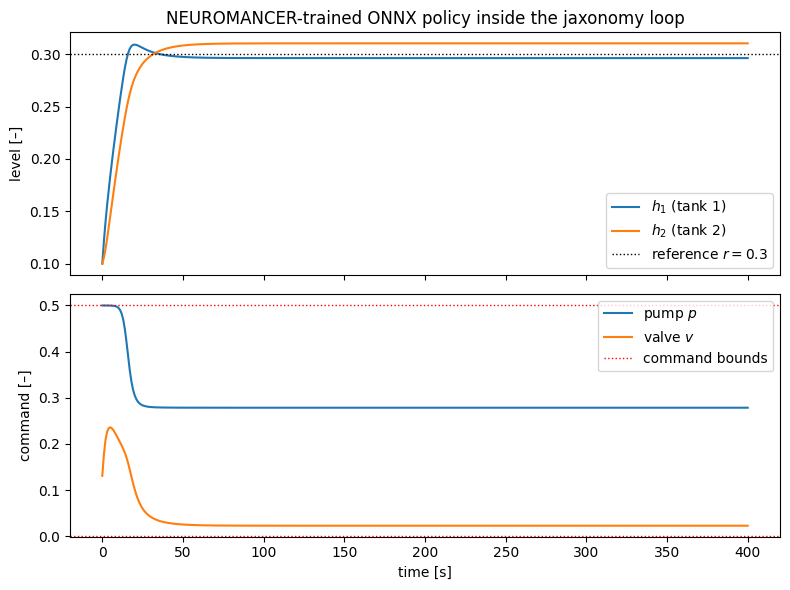

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax = axes[0]
ax.plot(t_rec, x_rec[:, 0], label="$h_1$ (tank 1)")
ax.plot(t_rec, x_rec[:, 1], label="$h_2$ (tank 2)")
ax.axhline(REF[0], color="k", ls=":", lw=1.0, label="reference $r = 0.3$")
ax.set_ylabel("level [–]")
ax.set_title("NEUROMANCER-trained ONNX policy inside the jaxonomy loop")
ax.legend(loc="lower right")

ax = axes[1]
ax.plot(t_rec, u_rec[:, 0], label="pump $p$")
ax.plot(t_rec, u_rec[:, 1], label="valve $v$")
ax.axhline(U_MAX, color="r", ls=":", lw=1.0, label="command bounds")
ax.axhline(U_MIN, color="r", ls=":", lw=1.0)
ax.set_xlabel("time [s]")
ax.set_ylabel("command [–]")
ax.legend(loc="upper right")

fig.tight_layout()
plt.show()

*Figure 1: closed-loop response of the imported policy. Top — tank levels $h_1$ (blue) and $h_2$ (orange) rise from 0.1 and settle within about 0.01 of the $r = 0.3$ setpoint (dotted) in roughly 20 s. Bottom — the pump rides its 0.5 rail for the first ~8 s of the fill, then settles near 0.28, close to the $p^* \approx 0.27$ of eq. (4); the valve settles near 0.02, close to the $v^* = 0$ the equilibrium analysis demands. Both commands stay inside the $[0, 0.5]$ box enforced by eq. (5).*

## 5. Validation: is this the same controller?

Plots that "look right" are not validation. The question is whether the jaxonomy loop computes the *same trajectory* as the framework that trained and exported the policy. We rebuild the exporting framework's closed loop — one policy evaluation and one RK4 step per sample period, the `System` semantics — in plain PyTorch, using the `policy_reference` we already verified against the graph.

One wrinkle makes two reference variants worth reporting. Because jaxonomy enabled x64, our diagram integrates the plant state in float64 while the policy computes in float32. The apples-to-apples reference mirrors exactly that (f64 state, f32 policy). The second variant is the strict all-float32 loop NEUROMANCER itself would run — its difference from the first is pure float32 accumulation noise in the *plant*, nothing to do with the ONNX transport.

In [13]:
if HAVE_TORCH:
    def two_tank_ode_torch(x, u):
        """Eqs. (1)-(2) in torch; dtype follows x."""
        h1 = torch.clip(x[..., 0:1], 0.0, 1.0)
        h2 = torch.clip(x[..., 1:2], 0.0, 1.0)
        pump = torch.clip(u[..., 0:1], 0.0, 1.0)
        valve = torch.clip(u[..., 1:2], 0.0, 1.0)
        dh1 = C1_NOM * (1.0 - valve) * pump - C2_NOM * torch.sqrt(h1)
        dh2 = (C1_NOM * valve * pump + C2_NOM * torch.sqrt(h1)
               - C2_NOM * torch.sqrt(h2))
        return torch.cat([dh1, dh2], dim=-1)

    def rollout_reference(dtype):
        """The exporting framework's loop: u_k = policy(x_k, r) once per ts,
        held across one RK4 step. Policy always float32 (as the ONNX graph);
        state integrated in `dtype`."""
        x = torch.tensor(X0, dtype=dtype).reshape(1, 2)
        r = torch.tensor(REF, dtype=dtype).reshape(1, 2)
        xs = [x]
        with torch.no_grad():
            for _ in range(N_CL):
                u = policy_reference(torch.cat([x, r], dim=-1), dtype=dtype)
                k1 = two_tank_ode_torch(x, u)
                k2 = two_tank_ode_torch(x + TS * k1 / 2.0, u)
                k3 = two_tank_ode_torch(x + TS * k2 / 2.0, u)
                k4 = two_tank_ode_torch(x + TS * k3, u)
                x = x + TS * (k1 / 6.0 + k2 / 3.0 + k3 / 3.0 + k4 / 6.0)
                xs.append(x)
        return torch.cat(xs, dim=0).numpy()

    x_ref_f64 = rollout_reference(torch.float64)  # mirrors the jaxonomy loop
    x_ref_f32 = rollout_reference(torch.float32)  # strict all-f32 semantics
    parity_f64 = float(np.abs(x_jax - x_ref_f64).max())
    parity_f32 = float(np.abs(x_jax - x_ref_f32).max())
    print(f"max|x_jaxonomy - x_reference| over {N_CL} closed-loop steps:")
    print(f"  vs f64-state / f32-policy reference: {parity_f64:.2e}")
    print(f"  vs all-float32 reference           : {parity_f32:.2e}")
    assert parity_f64 < 1e-4, "closed-loop parity failed"
else:
    print("torch not installed — skipping the closed-loop parity check; the "
          "shipped run recorded 3.6e-08 (f64 ref) and 1.6e-07 (f32 ref).")

max|x_jaxonomy - x_reference| over 400 closed-loop steps:
  vs f64-state / f32-policy reference: 3.84e-08
  vs all-float32 reference           : 1.62e-07


Closed-loop parity is $3.8\times10^{-8}$ against the matched-precision reference and $1.6\times10^{-7}$ against the strict all-float32 loop — over **400 sequential steps** of a feedback loop, where any semantic mismatch would compound exponentially, both numbers sit three to four orders of magnitude below any tolerance you would set for controller acceptance (say $10^{-4}$ on a unit-scale level). This agreement is precisely what the `ZeroOrderHold` buys: remove it and the loop still *tracks*, but step-for-step equivalence with the exporting framework is gone (exercise 2 measures how fast). The gap between the two reference variants — one decade — is the cost of float32 plant accumulation, not of the ONNX transport.

With identity established, the remaining closed-loop numbers are properties of the *policy*, not the port.

In [14]:
# Tracking quality of the imported controller on the nominal plant.
tail = t_rec >= (T_END - 100.0)
rms_tail100 = float(np.sqrt(np.mean((x_rec[tail] - REF) ** 2)))
print(f"tracking RMS of x vs r over the last 100 s: {rms_tail100:.5f}")
print(f"final levels : {x_jax[-1]}   (reference {REF})")
print(f"steady offset: {x_jax[-1] - REF}")

tracking RMS of x vs r over the last 100 s: 0.00778
final levels : [0.29625398 0.31034516]   (reference [0.3 0.3])
steady offset: [-0.00374602  0.01034516]


The tracking RMS over the final 100 s is **0.0078** — about 0.8% of full scale — dominated by small persistent offsets ($-0.004$ on $h_1$, $+0.010$ on $h_2$). Those biases are a property of the trained policy, not of the import: finite-horizon DPC has no integral action, so a small steady error costs less than the control effort it would take to remove. The torch reference reproduces the same offsets to better than $10^{-7}$.

### Actuator diagnostics

Before shipping any closed-loop result we run jaxonomy's actuator diagnostics on the commands actually applied to the plant. The pump and valve are *one-sided* actuators — resting at the lower rail is a natural operating point (eq. (4) says the optimal steady-state valve is exactly $v = 0$) — so we use `mode="upper_only"`: sitting at the *upper* rail is what would indicate authority exhaustion or a tuning bug.

In [15]:
sat_pump = analyze_saturation(u_rec[:, 0], lower=U_MIN, upper=U_MAX,
                              mode="upper_only", name="pump")
sat_valve = analyze_saturation(u_rec[:, 1], lower=U_MIN, upper=U_MAX,
                               mode="upper_only", name="valve")
osc_pump = analyze_control_oscillation(u_rec[:, 0], t_rec, name="pump")
osc_valve = analyze_control_oscillation(u_rec[:, 1], t_rec, name="valve")

for report in (sat_pump, sat_valve, osc_pump, osc_valve):
    print(report.message)
n_warn = sum(r.warning_triggered
             for r in (sat_pump, sat_valve, osc_pump, osc_valve))
print(f"\ndiagnostic warnings triggered: {n_warn}")

pump: 2% at upper=0.5, 0% at lower=0. [upper_only mode; only upper rail counts against threshold] Total saturated: 2% of 401 samples.
valve: 0% at upper=0.5, 0% at lower=0. [upper_only mode; only upper rail counts against threshold] Total saturated: 0% of 401 samples.
pump: 1 sign changes over 400.00 s = 0.00 crossings/s
valve: 1 sign changes over 400.00 s = 0.00 crossings/s

diagnostic warnings triggered: 0


No warnings. The pump touches its upper rail only during the first eight seconds of the fill transient (2% of samples) and then holds around 56% authority, consistent with the steady-state analysis; the valve never reaches either rail — the sigmoid of eq. (5) can approach but not touch its bounds, and it settles near 0.02, the near-zero optimum eq. (3) demands. Sign-change rates are essentially zero against the 5 crossings/s bang-bang threshold: the policy is smooth, not chattering.

Now for the part that justifies the whole import.

## 6. The payoff: a `jit`+`vmap` robustness sweep

The policy was trained against one nominal plant. Real pumps wear, orifices foul: suppose $c_1$ and $c_2$ each vary by ±30% across a fleet. Where does tracking degrade? That's 512 closed-loop simulations, each with a neural network in the loop — an expensive campaign in most tool chains, and precisely what the JAX side makes cheap.

Because jaxonnxruntime turned the graph into JAX primitives, one closed-loop rollout is a **pure function of the plant parameters**: a `lax.scan` whose body is *policy evaluation → one RK4 step* — exactly the sample-and-hold loop we just validated in section 5, now with $(c_1, c_2)$ as arguments. `jax.vmap` batches that function over the 512 parameter samples, and `jax.jit` compiles the entire batch — neural policy included — into a single XLA program. (We could equally `vmap` the full diagram simulation; the bare scan keeps the compiled object minimal and makes the timing legible.)

> **Note:** the kernel is running with x64 enabled (jaxonomy flipped it at import). The rollout below pins every array to `float32` explicitly, so the policy sees the same arithmetic it was trained and exported with regardless of the global flag.

In [16]:
# The policy as a JAX-traceable callable, prepared once from the graph.
rep = Backend.prepare(onnx.load(ONNX_PATH))


def policy_fn(xr):
    """xr (1, 4) f32 -> u (1, 2) f32. rep.run emits JAX primitives, so this
    traces under jit, vmap, and lax.scan."""
    return rep.run([xr])[0]


# Spot-check the third runtime in this notebook against onnxruntime before
# trusting it inside the sweep (vmapped, as the sweep will use it).
xr_probe_np = np.random.default_rng(SEED).random((64, 4), dtype=np.float32)
u_jaxrt = np.asarray(jax.vmap(lambda a: policy_fn(a[None, :])[0])(
    jnp.asarray(xr_probe_np)))
u_ortrt = sess.run(None, {"xr": xr_probe_np})[0]
rt_parity = float(np.abs(u_jaxrt - u_ortrt).max())
print(f"jaxonnxruntime (vmapped) <-> onnxruntime: max|du| = {rt_parity:.3e}")
assert rt_parity < 1e-5, "jaxonnxruntime does not match onnxruntime"

jaxonnxruntime (vmapped) <-> onnxruntime: max|du| = 1.490e-07


In [17]:
N_SAMPLES = 512   # plant-parameter draws
HORIZON = 200     # closed-loop steps per rollout [samples of ts = 1 s]
TAIL = 50         # steady-state window for the second metric


def rollout_rms(c1, c2):
    """Closed-loop tracking RMS for one (c1, c2) plant sample, float32.

    Section-5 semantics: policy evaluated once per ts, held across one RK4
    step. Returns (RMS over the full horizon, RMS over the last TAIL steps).
    """
    x0 = jnp.asarray(X0, dtype=jnp.float32)
    ref = jnp.asarray(REF, dtype=jnp.float32)

    def ode_f(x, u):
        h1 = jnp.clip(x[0], 0.0, 1.0)
        h2 = jnp.clip(x[1], 0.0, 1.0)
        pump = jnp.clip(u[0], 0.0, 1.0)
        valve = jnp.clip(u[1], 0.0, 1.0)
        dh1 = c1 * (1.0 - valve) * pump - c2 * jnp.sqrt(h1)
        dh2 = c1 * valve * pump + c2 * jnp.sqrt(h1) - c2 * jnp.sqrt(h2)
        return jnp.stack([dh1, dh2])

    def step(x, _):
        xr = jnp.concatenate([x, ref]).reshape(1, 4).astype(jnp.float32)
        u = policy_fn(xr)[0]                    # sample-and-hold policy eval
        k1 = ode_f(x, u)
        k2 = ode_f(x + TS * k1 / 2.0, u)
        k3 = ode_f(x + TS * k2 / 2.0, u)
        k4 = ode_f(x + TS * k3, u)
        x_next = x + TS * (k1 / 6.0 + k2 / 3.0 + k3 / 3.0 + k4 / 6.0)
        return x_next, x_next

    _, xs = jax.lax.scan(step, x0, None, length=HORIZON)
    err = xs - ref
    return jnp.sqrt(jnp.mean(err ** 2)), jnp.sqrt(jnp.mean(err[-TAIL:] ** 2))


sweep = jax.jit(jax.vmap(rollout_rms))
print(f"sweep = jit(vmap(rollout_rms)) over {N_SAMPLES} samples "
      f"x {HORIZON} steps")

sweep = jit(vmap(rollout_rms)) over 512 samples x 200 steps


In [18]:
# ±30% uniform spread around the nominal parameters.
key_c1, key_c2 = jax.random.split(jax.random.PRNGKey(SEED))
c1_samples = jax.random.uniform(key_c1, (N_SAMPLES,), jnp.float32,
                                0.7 * C1_NOM, 1.3 * C1_NOM)
c2_samples = jax.random.uniform(key_c2, (N_SAMPLES,), jnp.float32,
                                0.7 * C2_NOM, 1.3 * C2_NOM)

t0 = time.perf_counter()
rms_full, rms_tail50 = sweep(c1_samples, c2_samples)
rms_full.block_until_ready()
t_first = time.perf_counter() - t0

t0 = time.perf_counter()
rms_full, rms_tail50 = sweep(c1_samples, c2_samples)
rms_full.block_until_ready()
t_steady = time.perf_counter() - t0

print(f"{N_SAMPLES} rollouts x {HORIZON} steps, neural policy in the loop:")
print(f"  first call (includes jit compile): {t_first:.2f} s")
print(f"  steady-state call                : {t_steady * 1e3:.1f} ms "
      f"({t_steady / N_SAMPLES * 1e6:.0f} us per closed-loop rollout)")

# Nominal rollout sets the robustness threshold.
rms_nom, rms_nom_tail = [float(v) for v in
                         jax.jit(rollout_rms)(jnp.float32(C1_NOM),
                                              jnp.float32(C2_NOM))]
c1_np, c2_np = np.asarray(c1_samples), np.asarray(c2_samples)
rms_np, rms_tail_np = np.asarray(rms_full), np.asarray(rms_tail50)

print(f"\nnominal plant: RMS_full = {rms_nom:.4f}, RMS_last{TAIL} = {rms_nom_tail:.4f}")
print(f"full-horizon RMS : mean {rms_np.mean():.4f}, "
      f"p95 {np.percentile(rms_np, 95):.4f}, worst {rms_np.max():.4f}")
print(f"steady-state RMS : mean {rms_tail_np.mean():.4f}, "
      f"p95 {np.percentile(rms_tail_np, 95):.4f}, worst {rms_tail_np.max():.4f}")

bad = rms_np > 2.0 * rms_nom
i_worst = int(np.argmax(rms_np))
print(f"\nsamples with full-horizon RMS > 2x nominal: {int(bad.sum())}/{N_SAMPLES}")
print(f"worst sample: c1 = {c1_np[i_worst]:.4f}, c2 = {c2_np[i_worst]:.4f}, "
      f"RMS = {rms_np[i_worst]:.4f}  (c2/c1 = {c2_np[i_worst] / c1_np[i_worst]:.3f})")

512 rollouts x 200 steps, neural policy in the loop:
  first call (includes jit compile): 0.10 s
  steady-state call                : 7.1 ms (14 us per closed-loop rollout)

nominal plant: RMS_full = 0.0325, RMS_last50 = 0.0078
full-horizon RMS : mean 0.0352, p95 0.0495, worst 0.0662
steady-state RMS : mean 0.0115, p95 0.0210, worst 0.0385

samples with full-horizon RMS > 2x nominal: 1/512
worst sample: c1 = 0.0563, c2 = 0.0509, RMS = 0.0662  (c2/c1 = 0.905)


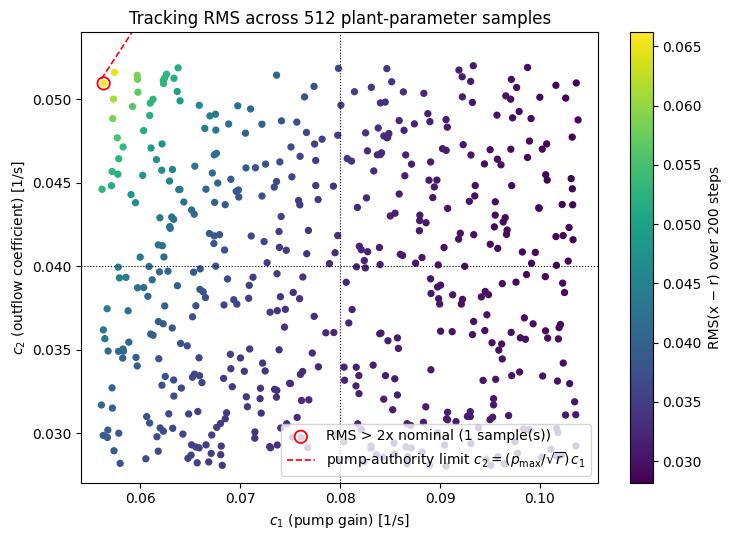

  quadrant c1<nom, c2<nom: mean RMS 0.0365   (0 of 146 flagged)
  quadrant c1<nom, c2>nom: mean RMS 0.0431   (1 of 115 flagged)
  quadrant c1>nom, c2<nom: mean RMS 0.0308   (0 of 125 flagged)
  quadrant c1>nom, c2>nom: mean RMS 0.0306   (0 of 126 flagged)


In [19]:
# Eq. (4) as a feasibility boundary: holding r needs p* = (c2/c1) sqrt(r)
# <= U_MAX, i.e. c2 <= (U_MAX / sqrt(r)) * c1. Overlay it on the scatter.
slope_feas = U_MAX / np.sqrt(REF[0])

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sc = ax.scatter(c1_np, c2_np, c=rms_np, cmap="viridis", s=18)
if bad.any():
    ax.scatter(c1_np[bad], c2_np[bad], facecolors="none", edgecolors="red",
               s=80, linewidths=1.3,
               label=f"RMS > 2x nominal ({int(bad.sum())} sample(s))")
c1_line = np.linspace(c1_np.min(), c1_np.max(), 2)
ax.plot(c1_line, slope_feas * c1_line, "r--", lw=1.2,
        label=r"pump-authority limit $c_2 = (p_{\max}/\sqrt{r})\,c_1$")
ax.axvline(C1_NOM, color="k", ls=":", lw=0.8)
ax.axhline(C2_NOM, color="k", ls=":", lw=0.8)
ax.set_xlim(c1_np.min() - 0.002, c1_np.max() + 0.002)
ax.set_ylim(c2_np.min() - 0.001, c2_np.max() + 0.002)
ax.set_xlabel("$c_1$ (pump gain) [1/s]")
ax.set_ylabel("$c_2$ (outflow coefficient) [1/s]")
ax.set_title(f"Tracking RMS across {N_SAMPLES} plant-parameter samples")
fig.colorbar(sc, label=f"RMS(x − r) over {HORIZON} steps")
ax.legend(loc="lower right")  # keep the fragile top-left corner unobstructed
fig.tight_layout()
plt.show()

# Which quadrant of the uncertainty box is fragile?
lo1, lo2 = c1_np < C1_NOM, c2_np < C2_NOM
for qname, m in [("c1<nom, c2<nom", lo1 & lo2), ("c1<nom, c2>nom", lo1 & ~lo2),
                 ("c1>nom, c2<nom", ~lo1 & lo2), ("c1>nom, c2>nom", ~lo1 & ~lo2)]:
    print(f"  quadrant {qname}: mean RMS {rms_np[m].mean():.4f}   "
          f"({int(bad[m].sum())} of {int(m.sum())} flagged)")

*Figure 2: robustness map. Each dot is one plant sample, colored by full-horizon tracking RMS (dark = good). Dotted black lines mark the nominal parameters; the dashed red line — the steady-state pump-authority limit from eq. (4) — clips the extreme top-left corner of the box. RMS degrades smoothly toward the top-left — weak pump (low $c_1$), fast drain (high $c_2$) — and the only sample flagged above $2\times$ nominal (red circle) sits hard against the authority line.*

The physics explains the map. Eq. (4) says holding $r$ costs $p^* = (c_2/c_1)\sqrt{r}$: as $c_1$ falls and $c_2$ rises, the required steady pump command climbs toward the $p_{\max} = 0.5$ rail, control margin shrinks, and a policy trained on the *nominal* ratio $c_2/c_1 = 0.5$ is asked to operate ever further from its training distribution. At the dashed line ($c_2/c_1 = p_{\max}/\sqrt{r} \approx 0.913$) the setpoint becomes strictly infeasible — no controller could hold it. The worst sample sits at $c_2/c_1 = 0.905$: still nominally feasible, but eq. (4) prices its setpoint at $p^* \approx 0.496$ — 99% of the rail, with nothing left for the transient, at nearly double the parameter ratio the policy was trained on. Its tracking error is an authority limit, not a network defect, and eq. (4) let us diagnose that without blaming the learning.

Two performance notes worth naming: mean RMS across the fleet is barely above nominal (0.035 vs 0.033) with p95 at 0.05 — the policy is robust over most of the ±30% box — and the steady-state sweep costs ~7 ms for all 512 rollouts (~14 µs per closed-loop simulation with a neural network in the loop), so this analysis scales to millions of samples or to gradient-based worst-case search.

## 7. Failure modes

Where this pattern breaks, concretely:

- **No integral action.** Finite-horizon DPC tolerates a small steady error (here up to ≈0.01 on a 0.3 setpoint). On a *mismatched* plant the offset grows with the mismatch — that is most of the RMS gradient in Figure 2. If your spec demands zero steady-state error, retrain with an integral-augmented input, or close an outer trim loop around the imported policy.
- **Broken hold semantics.** Wire the policy straight into the plant (no `ZeroOrderHold`) and the RK4 stages each query the network at intermediate states. The loop still stabilizes the tanks here, but step-for-step parity with the exporting framework is destroyed — the controller you validated is no longer the controller you run. This failure is *silent*: both loops "work".
- **Extrapolation outside the training envelope.** The policy saw $x_0 \in [0, 0.5]$ and references in $[0.1, 0.5]$. Eq. (5) keeps commands bounded whatever you feed it, so nothing crashes — it just tracks badly. Asking for $r = 0.8$ (never seen; $p^* = 0.447$, nearly the rail) is a qualitatively different regime from $r = 0.3$.
- **Infeasible plants look like bad networks.** For $c_2/c_1 > p_{\max}/\sqrt{r}$ no controller holds the setpoint. Check the authority limit of eq. (4) before debugging the policy.
- **Dtype drift at the boundary.** With x64 on globally, any un-cast literal or state promotes to float64. Keep the casts at the ONNX boundary explicit (as `ConcatXR` and `rollout_rms` do) so the network always computes in the float32 arithmetic it was trained, exported, and parity-checked with.

## 8. Exercises

1. **Setpoint step (code).** Replace the `Constant` reference with `jaxonomy.library.Step(start_value=0.3, end_value=0.45, step_time=200.0)` feeding both channels (or a small custom source block). The policy was trained on piecewise-constant references, so it should handle the change. Measure the settling time to within ±0.01 of the new setpoint, and verify parity still holds against a torch reference fed the same profile.
2. **Break the hold (code).** Remove the `ZeroOrderHold` and wire `SqueezeU` directly into the plant. Re-run the parity cell: how large is $\max|x_{\text{jax}} - x_{\text{ref}}|$ after 400 steps now? Plot the two trajectories — why does the loop still track even though parity is gone, and which of the two semantics would you trust for hardware deployment?
3. **The valve at steady state (conceptual).** Re-derive eq. (3) and explain physically why $h_2^*$ cannot depend on the valve. Then compute the equilibrium $(h_1^*, h_2^*)$ for $v = 0.2$, $p = 0.3$, and characterize the set of *unequal* setpoints $(r_1, r_2)$ the valve makes reachable.
4. **Map the envelope (open-ended).** The sweep varied only $(c_1, c_2)$. Extend `rollout_rms` and `vmap` over initial state and reference too, or inject sensor noise into `x` before the policy input. Produce an "operating map" of the imported controller: over what region of (plant × task) space does the shipped network meet a 0.02 steady-state RMS spec? Where would you retrain versus gain-schedule?

## 9. Key takeaways

- ONNX carries a NEUROMANCER DPC policy into jaxonomy essentially losslessly: export parity ~$3\times10^{-7}$, closed-loop parity $3.8\times10^{-8}$ over 400 feedback steps.
- Match the **semantics**, not just the weights: `ZeroOrderHold(dt=ts)` reproduces the sample-and-hold discipline the policy was trained under; without it you silently validate a different controller.
- jaxonnxruntime turns the graph into JAX primitives, so the imported network composes with `jit`, `vmap`, and `lax.scan` like a native block — that, not the file format, is the point of the import.
- The receiving stack's payoff: 512 closed-loop robustness rollouts in ~7 ms steady state, cheap enough to make Monte-Carlo robustness a routine check.
- First-principles analysis and the sweep corroborate each other: eq. (4)'s pump-authority limit predicts exactly the fragile weak-pump/fast-drain corner the data flags.
- Run actuator diagnostics (`analyze_saturation`, `analyze_control_oscillation`) on every closed loop you ship — cheap insurance against silent tuning bugs.

**Next steps.** [Part 2](pinn_across_stacks_part_2_neural_dae.ipynb) makes gradients cross the stack boundary — a neural correction trained *inside* an acausal DAE through the implicit BDF solve, and a torch policy trained through the jaxonomy plant via `dlpack`. [Part 3](pinn_across_stacks_part_3_fmi_cosim.ipynb) goes tool-neutral with FMI co-simulation. For the DPC method itself implemented natively in jaxonomy, see the [two-tank DPC tutorial](dpc_two_tank_reference_tracking.ipynb); for the FMU machinery used in Part 3, the [FMU export round-trip](fmi_export_roundtrip.ipynb).

## References

1. J. Drgoňa, A. Tuor, and D. Vrabie, "Learning Constrained Parametric Differentiable Predictive Control Policies With Guarantees," *IEEE Transactions on Systems, Man, and Cybernetics: Systems*, 2024. [arXiv:2004.11184](https://arxiv.org/abs/2004.11184).
2. NEUROMANCER — Neural Modules with Adaptive Nonlinear Constraints and Efficient Regularizations. J. Drgoňa et al., Pacific Northwest National Laboratory. [github.com/pnnl/neuromancer](https://github.com/pnnl/neuromancer).
3. Two-tank benchmark: `psl.systems['TwoTank']` in NEUROMANCER's Python Systems Library, adapted from the APMonitor level-control problem, [apmonitor.com/do/index.php/Main/LevelControl](https://apmonitor.com/do/index.php/Main/LevelControl).
4. jaxonnxruntime — ONNX models as JAX functions. [github.com/google/jaxonnxruntime](https://github.com/google/jaxonnxruntime).
5. ONNX — Open Neural Network Exchange. J. Bai, F. Lu, K. Zhang, et al. [github.com/onnx/onnx](https://github.com/onnx/onnx).